<a href="https://colab.research.google.com/github/emt0147t/SIC26/blob/main/reportweek1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Thực hiện hồi quy tuyến tính trong Python**
Ở đây chúng tôi áp dụng hồi quy tuyến tính cho tập dữ liệu nhà ở để dự đoán giá nhà. Mã Python sau đây minh họa cách triển khai mô hình này.



Tập dữ liệu `Housing.csv` ở được tải bằng cách sử dụng kích thước lô làm đặc điểm đầu vào và giá làm biến mục tiêu. Dữ liệu được chia thành các tập huấn luyện và kiểm tra và mô hình hồi quy tuyến tính được huấn luyện. Dự đoán về dữ liệu thử nghiệm được vẽ dựa trên các giá trị thực tế.

Plot saved as regression_plot.png


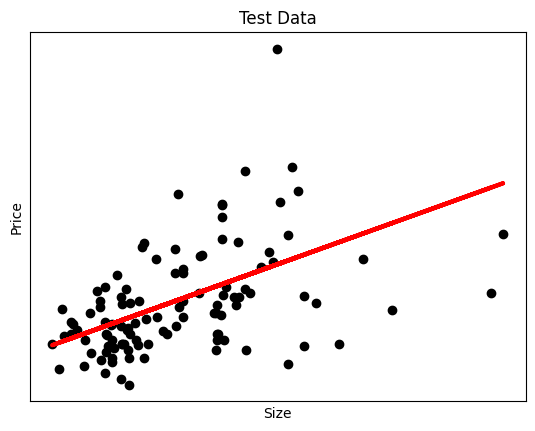

In [ ]:
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv("Housing.csv")
Y = df['price']
X = df['lotsize']
X = X.to_numpy().reshape(len(X), 1)
Y = Y.to_numpy().reshape(len(Y), 1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

plt.scatter(X_test, Y_test, color='black')
plt.title('Test Data')
plt.xlabel('Size')
plt.ylabel('Price')
plt.xticks(())
plt.yticks(())
regr = linear_model.LinearRegression()
regr.fit(X_train, Y_train)

plt.plot(X_test, regr.predict(X_test), linewidth=3, color='red')
plt.savefig("regression_plot.png")
print("Plot saved as regression_plot.png")

###**Hoạt động của Semi-Supervised Learning**

In [ ]:
#import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import accuracy_score

iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

In [ ]:
#mask labels
labels = np.copy(y)
rng = np.random.RandomState(42)
mask = rng.rand(len(y)) < 0.1
labels[~mask] = -1
print(f"Labeled: {np.sum(mask)}, Unlabeled: {np.sum(~mask)}")

Labeled: 18, Unlabeled: 132


In [ ]:
#label propagation
model = LabelPropagation()
model.fit(X, labels)

LabelPropagation()

In [ ]:
y_pred = model.transduction_
acc_labeled = accuracy_score(y[mask], y_pred[mask])
acc_overall = accuracy_score(y, y_pred)
print(f"Acc (on original labeled subset): {acc_labeled:.3f}")
print(f"Acc (overall after propagation): {acc_overall:.3f}")

Acc (on original labeled subset): 1.000
Acc (overall after propagation): 0.707


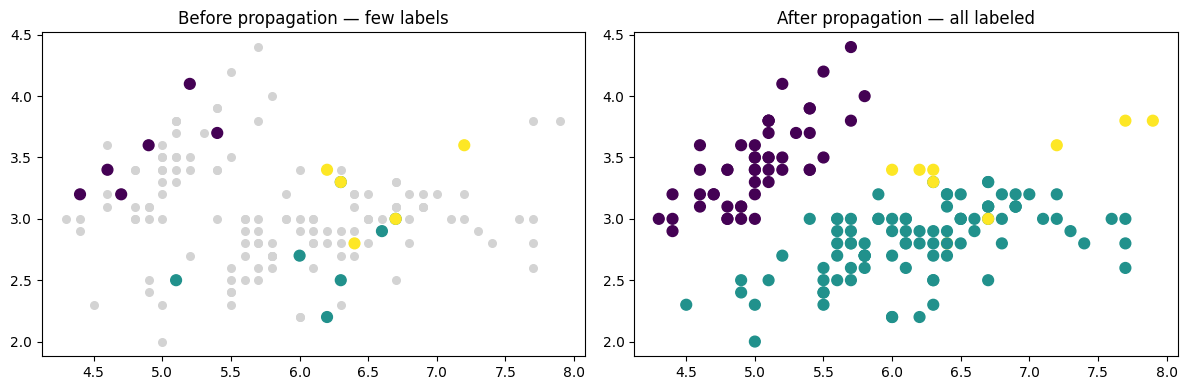

In [ ]:
#visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(X[:, 0], X[:, 1], c='lightgray', s=30)
ax[0].scatter(X[mask, 0], X[mask, 1], c=y[mask], cmap='viridis', s=60)
ax[0].set_title("Before propagation — few labels")

ax[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=60)
ax[1].set_title("After propagation — all labeled")

plt.tight_layout()
plt.show()

###**Linear Regression**

In [ ]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt

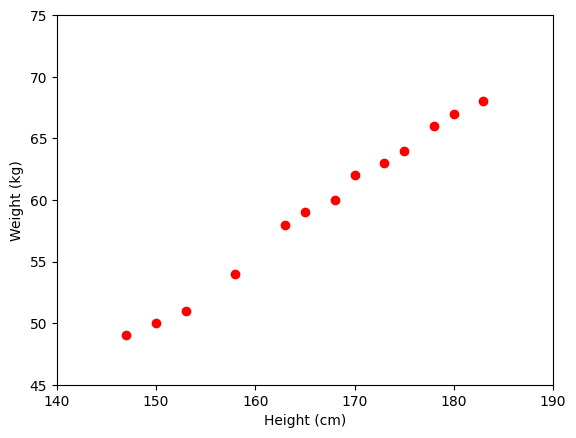

In [ ]:
# height (cm)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
# weight (kg)
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T
# Visualize data
plt.plot(X, y, 'ro')
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

Từ đồ thị này ta thấy rằng dữ liệu được sắp xếp gần như theo 1 đường thẳng, vậy mô hình Linear Regression nhiều khả năng sẽ cho kết quả tốt:

(cân nặng) = w_1*(chiều cao) + w_0

w =  [[-33.73541021]
 [  0.55920496]]


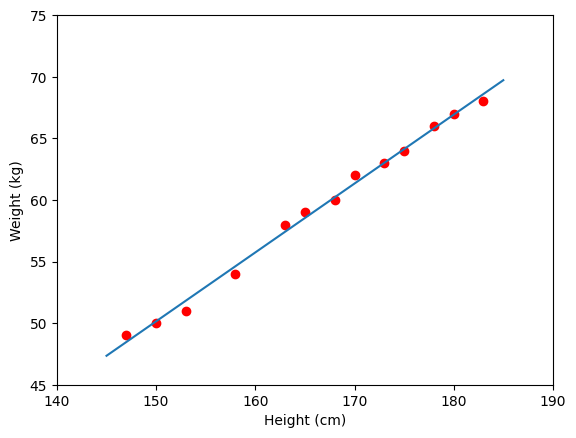

In [ ]:
# Building Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

# Calculating weights of the fitting line
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)
# Preparing the fitting line
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

# Drawing the fitting line
plt.plot(X.T, y.T, 'ro')     # data
plt.plot(x0, y0)               # the fitting line
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()



In [ ]:
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0

print( u'Predict weight of person with height 155 cm: %.2f (kg), real number: 52 (kg)'  %(y1) )
print( u'Predict weight of person with height 160 cm: %.2f (kg), real number: 56 (kg)'  %(y2) )

Predict weight of person with height 155 cm: 52.94 (kg), real number: 52 (kg)
Predict weight of person with height 160 cm: 55.74 (kg), real number: 56 (kg)


###**MNIST**

In [ ]:
import numpy as np
!pip install python-mnist
from mnist import MNIST
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

df_mnist = pd.read_csv('/content/sample_data/mnist_test.csv', header=None)
X_all = df_mnist.iloc[:, 1:].values

X0 = X_all[:1000, :] / 255.0
X = X0

K = 10
kmeans = KMeans(n_clusters=K, n_init=10).fit(X)

pred_label = kmeans.predict(X)
print("Phân cụm hoàn tất bằng dữ liệu nội bộ.")

Phân cụm hoàn tất bằng dữ liệu nội bộ.


<class 'numpy.ndarray'>
(784, 10)


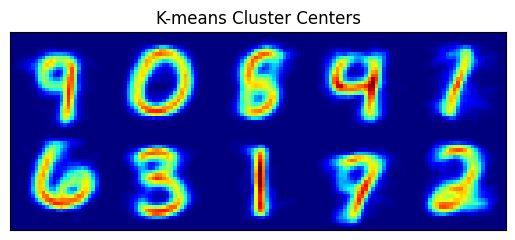

Ảnh đã được lưu thành aa.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_network(A, k, col):
    N, p = A.shape
    sz = int(np.sqrt(N))
    h = int(np.ceil(p / col))
    grid = np.zeros((h * sz, col * sz))
    for i in range(p):
        r = i // col
        c = i % col
        grid[r*sz:(r+1)*sz, c*sz:(c+1)*sz] = A[:, i].reshape(sz, sz)
    return grid

print(type(kmeans.cluster_centers_.T))
print(kmeans.cluster_centers_.T.shape)

# Sử dụng hàm vừa định nghĩa
A_display = display_network(kmeans.cluster_centers_.T, K, 5)

f1 = plt.imshow(A_display, interpolation='nearest', cmap="jet")
f1.axes.get_xaxis().set_visible(False)
f1.axes.get_yaxis().set_visible(False)
plt.title("K-means Cluster Centers")
plt.show()

cmap = plt.cm.jet
norm = plt.Normalize(vmin=A_display.min(), vmax=A_display.max())
image_to_save = cmap(norm(A_display))

plt.imsave('aa.png', image_to_save)
print("Ảnh đã được lưu thành aa.png")

In [ ]:
print(type(pred_label))
print(pred_label.shape)
print(type(X0))

<class 'numpy.ndarray'>
(1000,)
<class 'numpy.ndarray'>


In [ ]:
N0 = 20
X1 = np.zeros((N0*K, 784))
X2 = np.zeros((N0*K, 784))

for k in range(K):
    Xk = X0[pred_label == k, :]

    center_k = [kmeans.cluster_centers_[k]]
    # Sửa lỗi truyền đối số ở đây
    neigh = NearestNeighbors(n_neighbors=N0).fit(Xk)
    dist, nearest_id = neigh.kneighbors(center_k, N0)

    X1[N0*k: N0*k + N0,:] = Xk[nearest_id, :]
    X2[N0*k: N0*k + N0,:] = Xk[:N0, :]

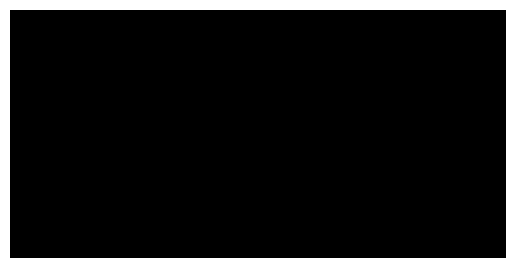

In [ ]:
plt.axis('off')
A = display_network(X2.T, K, N0)
f2 = plt.imshow(A, interpolation='nearest' )
plt.gray()
plt.show()


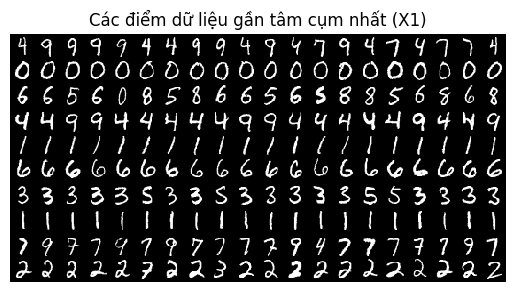

Ảnh các điểm gần tâm cụm đã được lưu thành cc.png


In [ ]:
plt.axis('off')
A_nearest = display_network(X1.T, K, N0)
f3 = plt.imshow(A_nearest, interpolation='nearest')
plt.gray()
plt.title("Các điểm dữ liệu gần tâm cụm nhất (X1)")
plt.show()

plt.imsave('cc.png', A_nearest, cmap='gray')
print("Ảnh các điểm gần tâm cụm đã được lưu thành cc.png")

###**Segmentation and Compression**

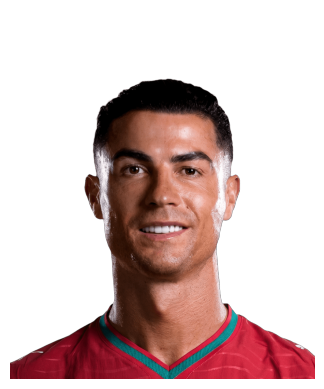

In [ ]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

img = mpimg.imread('/content/885.jpg')
plt.imshow(img)
imgplot = plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
X = img.reshape((img.shape[0]*img.shape[1], img.shape[2]))

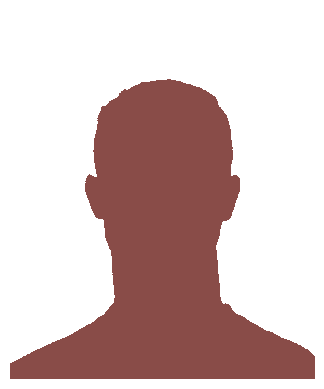

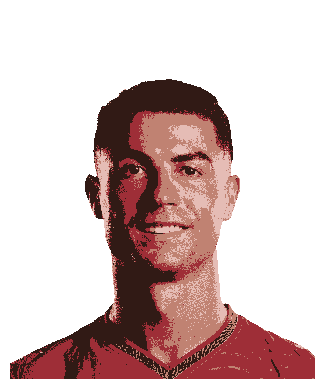

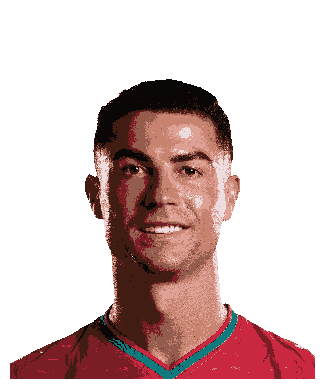

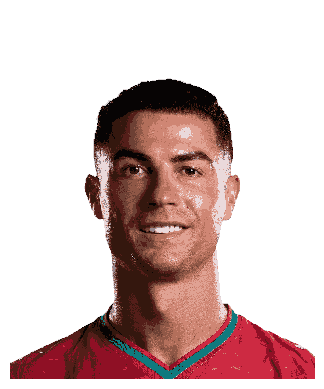

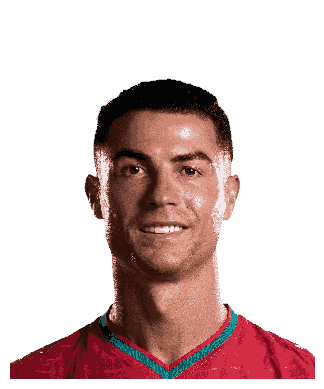

In [ ]:
for K in [2, 5, 10, 15, 20]:
    kmeans = KMeans(n_clusters=K).fit(X)
    label = kmeans.predict(X)

    img4 = np.zeros_like(X)
    # replace each pixel by its center
    for k in range(K):
        img4[label == k] = kmeans.cluster_centers_[k]
    # reshape and display output image
    img5 = img4.reshape((img.shape[0], img.shape[1], img.shape[2]))
    plt.imshow(img5, interpolation='nearest')
    plt.axis('off')
    plt.show()

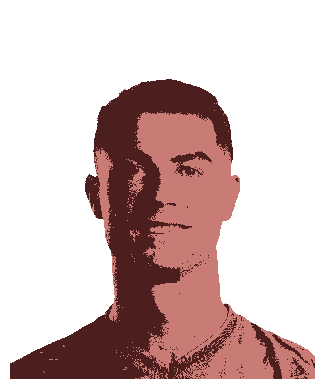

In [ ]:
for K in [3]:
    kmeans = KMeans(n_clusters=K).fit(X)
    label = kmeans.predict(X)

    img4 = np.zeros_like(X)
    # replace each pixel by its center
    for k in range(K):
        img4[label == k] = kmeans.cluster_centers_[k]
    # reshape and display output image
    img5 = img4.reshape((img.shape[0], img.shape[1], img.shape[2]))
    plt.imshow(img5, interpolation='nearest')
    plt.axis('off')
    plt.show()

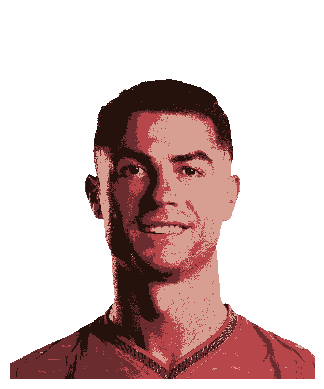

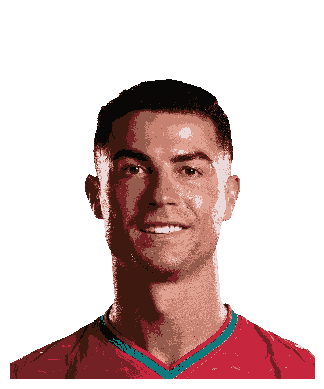

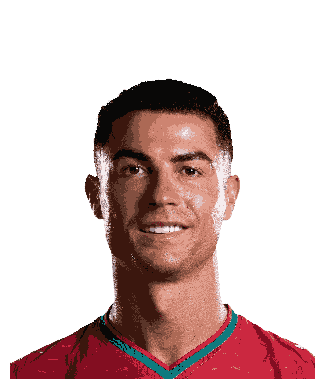

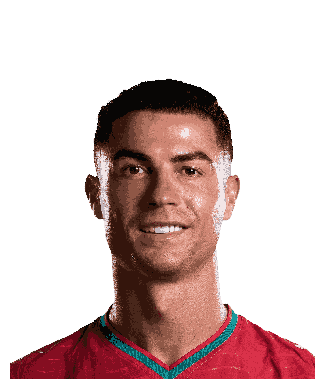

In [ ]:
for K in [5, 10, 15, 20]:
    kmeans = KMeans(n_clusters=K).fit(X)
    label = kmeans.predict(X)

    img4 = np.zeros_like(X)
    # replace each pixel by its center
    for k in range(K):
        img4[label == k] = kmeans.cluster_centers_[k]
    # reshape and display output image
    img5 = img4.reshape((img.shape[0], img.shape[1], img.shape[2]))
    plt.imshow(img5, interpolation='nearest')
    plt.axis('off')
    plt.show()

###**Iris flower**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors, datasets

In [ ]:
iris = datasets.load_iris()
iris_X = iris.data
iris_y = iris.target
print('Number of classes: %d' % len(np.unique(iris_y)))
print('Number of data points: %d' % len(iris_y))


X0 = iris_X[iris_y == 0,:]
print('\nSamples from class 0:\n', X0[:5,:])

X1 = iris_X[iris_y == 1,:]
print('\nSamples from class 1:\n', X1[:5,:])

X2 = iris_X[iris_y == 2,:]
print('\nSamples from class 2:\n', X2[:5,:])

Number of classes: 3
Number of data points: 150

Samples from class 0:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Samples from class 1:
 [[7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.9 1.5]
 [5.5 2.3 4.  1.3]
 [6.5 2.8 4.6 1.5]]

Samples from class 2:
 [[6.3 3.3 6.  2.5]
 [5.8 2.7 5.1 1.9]
 [7.1 3.  5.9 2.1]
 [6.3 2.9 5.6 1.8]
 [6.5 3.  5.8 2.2]]


In [ ]:
#Tách training và test sets

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
     iris_X, iris_y, test_size=50)

print("Training size: %d" % len(y_train))
print("Test size    : %d" % len(y_test))

Training size: 100
Test size    : 50


In [ ]:
from sklearn import neighbors
from sklearn.metrics import accuracy_score

# Khởi tạo mô hình KNN với 1 láng giềng gần nhất
clf = neighbors.KNeighborsClassifier(n_neighbors = 1, p = 2)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Print results for 20 test data points:")
print("Predicted labels: ", y_pred[:20])
print("Ground truth    : ", y_test[:20])

# Tính toán độ chính xác
print("Accuracy: %.2f %%" %(100*accuracy_score(y_test, y_pred)))

Print results for 20 test data points:
Predicted labels:  [0 1 0 0 2 1 2 1 1 0 2 0 2 2 2 1 0 2 2 0]
Ground truth    :  [0 1 0 0 2 1 2 1 2 0 1 0 2 2 2 1 0 2 2 0]
Accuracy: 94.00 %


In [ ]:
clf = neighbors.KNeighborsClassifier(n_neighbors = 10, p = 2)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy of 10NN with major voting: %.2f %%" %(100*accuracy_score(y_test, y_pred)))

Accuracy of 10NN with major voting: 96.00 %


In [ ]:
clf = neighbors.KNeighborsClassifier(n_neighbors = 10, p = 2, weights = 'distance')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy of 10NN (1/distance weights): %.2f %%" %(100*accuracy_score(y_test, y_pred)))

Accuracy of 10NN (1/distance weights): 96.00 %
